In [1]:
import glob
import json
import gzip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import networkx as nx

# Prepare dataset for visualizations

In [2]:
def iterate_publication_data(filename):
    filteredTypes = {"paratext", "dataset", "report", "peer-review", "editorial" , "reference-entry", "review", "dissertation", "erratum", "other", "letter", "report-component"}
    pdata = json.loads(gzip.open(fname, "rt").read())

    filteredPub = list()
    for pub in pdata:
        if pub["type"] in filteredTypes:
            continue
        filteredPub.append(pub)

    return filteredPub

typeCount = dict()
for fname in glob.glob("../data/publications/*.gz"):
    for pub in iterate_publication_data(fname):
        if pub["type"] not in typeCount:
            typeCount[pub["type"]] = 0
        typeCount[pub["type"]] += 1

print(typeCount)


{'book': 220, 'article': 8628, 'book-chapter': 1243, 'preprint': 3283}


In [3]:

authorPubIds = dict()
publicationData = dict()

for fname in glob.glob("../data/publications/*.json.gz"):
    authorId = fname.split("/")[-1].split(".")[0].lower()
    authorPubIds[authorId] = set()

    #pubs = json.loads(gzip.open(fname, "rt").read())
    pubs = iterate_publication_data(fname)
    
    #print(pubs[0])
    # id, doi, title, publication_year, authorships, cited_by_count, fwci, counts_by_year
    for pub in pubs:
        authors = list()
        for a in pub["authorships"]:
            authors.append({
                "id": a["author"]["id"].split("/")[-1].lower() if a["author"]["id"] != None else None,
                "name": a["author"]["display_name"],
                "orcid": a["author"]["orcid"].split("/")[-1].lower() if a["author"]["orcid"] != None else None
            })

        pid = pub["id"].split("/")[-1].lower()
        authorPubIds[authorId].add(pid)
        publicationData[pid] = {
            "doi": pub["doi"],
            "title": pub["title"],
            "year": pub["publication_year"],
            "authors": authors,
            "n_citation": pub["cited_by_count"],
            "fwci": pub["fwci"]
        }

with open("../data/publications.json", "w") as fl:
    fl.write(json.dumps(publicationData))
    
print("{} publications saved".format(len(publicationData)))


12134 publications saved


In [4]:
orcid2oa = dict()
authorData = dict()
for fname in glob.glob("../data/profiles/*.json"):
    temp = json.loads(open(fname, "r").read())
    orcid2oa[temp["orcid"]] = authorId
    #print(temp)
    # "id", "orcid", "display_name", 'works_count', 'cited_by_count', "summary_stats", "last_known_institutions"
    authorId = temp["id"].split("/")[-1].lower()
    authorData[authorId] = {
        "orcid": temp["orcid"],
        "name": temp["display_name"],
        "n_work": temp["works_count"],
        "n_citation": temp["cited_by_count"],
        #"institute": temp["last_known_institutions"][0]["display_name"],
        "stat_h": temp["summary_stats"]["h_index"],
        "stat_i10": temp["summary_stats"]["i10_index"],
        "yearly_counts": temp["counts_by_year"],
        "publications": list(authorPubIds[authorId])
    }

with open("../data/authors.json", "w") as fl:
    fl.write(json.dumps(authorData))
    
print("{} authors saved".format(len(authorData)))


116 authors saved


# Build networks

In [5]:
# Load publications from the book

groupsData = json.loads(open("../data/groups-updated.json", "r").read())

uniqueOrcid = set()
for chapter in groupsData["groups"]:
    for author in chapter["authors"]:
        if author["orcid"] != None:
            uniqueOrcid.add(author["orcid"])
print(len(uniqueOrcid))

116


### Build co-author network

In [6]:
# Prepare data
coauthors = dict()

for fname in glob.glob("../data/publications/*.json.gz"):
    bid = fname.split("/")[-1].split(".")[0].lower()
    coauthors[bid] = dict()
    pdata = iterate_publication_data(fname)
    for p in pdata:
        try:
            for author in p["authorships"]:
                aid = author["author"]["id"].split("/")[-1].lower()
                if aid not in coauthors[bid]:
                    coauthors[bid][aid] = 0
                coauthors[bid][aid] += 1
        except:
            pass
print(len(coauthors))

# Add co-authors from books chapters
for pub in groupsData["groups"]:
    authors = [orcid2oa[a["orcid"]] for a in pub["authors"] if a["orcid"] in orcid2oa]
    for i in range(len(authors)):
        for j in range(i+1, len(authors)):
            if authors[j] not in coauthors[authors[i]]:
                coauthors[authors[i]][authors[i]] = 0
            coauthors[authors[i]][authors[i]] += 1


116


In [7]:
coauthorNet = nx.Graph()

authorIds = list(authorData.keys())

for i in range(len(authorIds)):
    for j in range(i+1, len(authorIds)):
        
        try:
            if (authorIds[j] in coauthors[authorIds[i]]) or (authorIds[i] in coauthors[authorIds[j]]):
                w = (coauthors[authorIds[i]][authorIds[j]] + coauthors[authorIds[j]][authorIds[i]]) * 0.5
                coauthorNet.add_edge(authorIds[i], authorIds[j], weight= w)
        except:
            pass

for n in coauthorNet.nodes():
    coauthorNet.nodes[n]["name"] = authorData[n]["name"]
    coauthorNet.nodes[n]["log-work-count"] = np.log10(authorData[n]["n_work"]+1)
    coauthorNet.nodes[n]["log-cited_by_count"] = np.log10(authorData[n]["n_citation"]+1)

print(coauthorNet.number_of_nodes(), coauthorNet.number_of_edges()) 

with open("../data/coauthor-net.edges", "w") as fl:
    for e,d,v in coauthorNet.edges(data=True):
        fl.write("{},{},{}\n".format(e,d,v["weight"]))


109 233


## Build co-reference network

In [36]:
# Prepare data
authorReferences = dict()

for fname in glob.glob("../data/publications/*.json.gz"):
    bid = fname.split("/")[-1].split(".")[0].lower()
    authorReferences[bid] = dict()
    pdata = iterate_publication_data(fname)
    for p in pdata:
        try:
            for ref in p["referenced_works"]:
                r = ref.split("/")[-1].lower()
                if r not in authorReferences[bid]:
                    authorReferences[bid][r] = 0
                authorReferences[bid][r] += 1
        except:
            pass
print(len(authorReferences))

116


In [37]:
cocitingNet = nx.Graph()

authorIds = list(authorData.keys())

for i in range(len(authorIds)):
    cocitingNet.add_node(authorIds[i])
    for j in range(i+1, len(authorIds)):
        r1 = set(authorReferences[authorIds[i]].keys())
        r2 = set(authorReferences[authorIds[j]].keys())
        if min(len(r1), len(r2)) > 0:
            w = len(r1 & r2) / min(len(r1), len(r2))
            if w > 0:
                cocitingNet.add_edge(authorIds[i], authorIds[j], weight= w)

for n in cocitingNet.nodes():
    cocitingNet.nodes[n]["name"] = authorData[n]["name"]
    cocitingNet.nodes[n]["log-work-count"] = np.log10(authorData[n]["n_work"]+1)
    cocitingNet.nodes[n]["log-cited_by_count"] = np.log10(authorData[n]["n_citation"]+1)

print(cocitingNet.number_of_nodes(), cocitingNet.number_of_edges()) 

116 5243


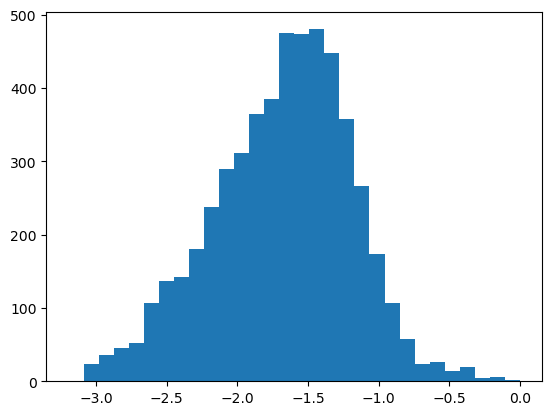

In [38]:
_ = plt.hist([np.log10(v["weight"]) for e,d,v in cocitingNet.edges(data=True)], bins=30)

In [39]:
with open("../data/cociting-net.edges", "w") as fl:
    for e,d,v in cocitingNet.edges(data=True):
        if v["weight"] > 0.1:
            fl.write("{},{},{}\n".format(e,d,v["weight"]))

## Build co-citation network

In [ ]:

authorCitations = dict()

for fname in glob.glob("../data/publications/*.json.gz"):
    bid = fname.split("/")[-1].split(".")[0].lower()
    authorCitations[bid] = dict()
    pdata = iterate_publication_data(fname)
    for pub in pdata:
        pid = pub["id"].split("/")[-1]
        
        try:
            cdata = json.loads(open("../data/citations/{}.json".format(pid), "r").read())
        except:
            cdata = list()
        
        if len(cdata) == 0:
            continue
        
        for cpub in cdata:
            cid = cpub["id"].split("/")[-1]
            if cid not in authorCitations[bid]:
                authorCitations[bid][cid] = 0
            authorCitations[bid][cid] += 1
print(len(authorCitations))

In [ ]:
cocitationNet = nx.Graph()

authorIds = list(authorData.keys())

for i in range(len(authorIds)):
    cocitationNet.add_node(authorIds[i])
    for j in range(i+1, len(authorIds)):
        r1 = set(authorCitations[authorIds[i]].keys())
        r2 = set(authorCitations[authorIds[j]].keys())
        if min(len(r1), len(r2)) > 0:
            w = len(r1 & r2) / min(len(r1), len(r2))
            if w > 0:
                cocitationNet.add_edge(authorIds[i], authorIds[j], weight= w)

for n in cocitationNet.nodes():
    cocitationNet.nodes[n]["name"] = authorData[n]["name"]
    cocitationNet.nodes[n]["log-work-count"] = np.log10(authorData[n]["n_work"]+1)
    cocitationNet.nodes[n]["log-cited_by_count"] = np.log10(authorData[n]["n_citation"]+1)

print(cocitationNet.number_of_nodes(), cocitationNet.number_of_edges()) 

31 49


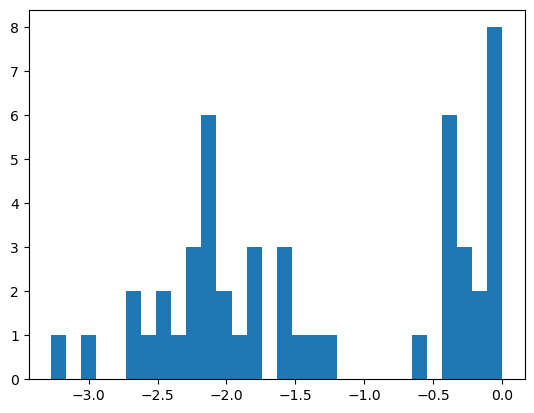

In [ ]:
_ = plt.hist([np.log10(v["weight"]) for e,d,v in cocitationNet.edges(data=True)], bins=30)

In [22]:
with open("../data/cocitation-net.edges", "w") as fl:
    for e,d,v in cocitationNet.edges(data=True):
        if v["weight"] > 0.1:
            fl.write("{},{},{}\n".format(e,d,v["weight"]))

## Build topical-similarity network

In [32]:
authorTopics = dict()

for fname in glob.glob("../data/publications/*.json.gz"):
    bid = fname.split("/")[-1].split(".")[0].lower()
    authorTopics[bid] = dict()
    pdata = iterate_publication_data(fname)
    for pub in pdata:
        for t in pub["topics"]:
            if t["display_name"] not in authorTopics[bid]:
                authorTopics[bid][t["display_name"]] = 0
            authorTopics[bid][t["display_name"]] += t["score"]
            

In [33]:
def cosine_similarity(dict1, dict2):
    all_keys = set(dict1.keys()).union(set(dict2.keys()))

    dot_product, norm_a, norm_b = 0, 0, 0
    for key in all_keys:
        val_a = dict1.get(key, 0)
        val_b = dict2.get(key, 0)
        
        dot_product += val_a * val_b
        norm_a += val_a ** 2
        norm_b += val_b ** 2
    magnitude = np.sqrt(norm_a) * np.sqrt(norm_b)    
    if not magnitude:
        return 1.0  # Default to max distance if a vector is empty
    similarity = dot_product / magnitude
    return similarity

topicSimNet = nx.Graph()

authorIds = list(authorData.keys())

for i in range(len(authorIds)):
    topicSimNet.add_node(authorIds[i])
    for j in range(i+1, len(authorIds)):
        w = cosine_similarity(authorTopics[authorIds[i]], authorTopics[authorIds[j]])
        if w > 0:
            topicSimNet.add_edge(authorIds[i], authorIds[j], weight= w)

for n in topicSimNet.nodes():
    topicSimNet.nodes[n]["name"] = authorData[n]["name"]
    topicSimNet.nodes[n]["log-work-count"] = np.log10(authorData[n]["n_work"]+1)
    topicSimNet.nodes[n]["log-cited_by_count"] = np.log10(authorData[n]["n_citation"]+1)

print(topicSimNet.number_of_nodes(), topicSimNet.number_of_edges()) 

116 6143


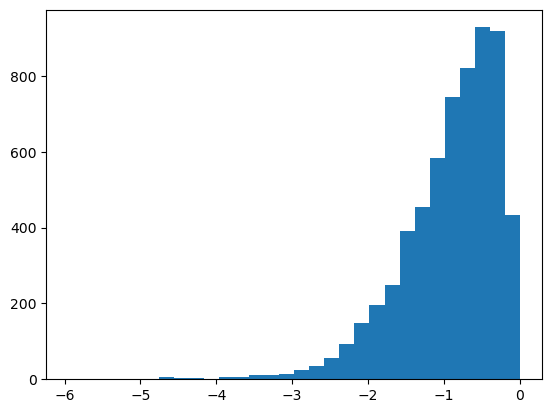

In [34]:
_ = plt.hist([np.log10(v["weight"]) for e,d,v in topicSimNet.edges(data=True)], bins=30)

In [35]:
with open("../data/fieldsim-net.edges", "w") as fl:
    for e,d,v in topicSimNet.edges(data=True):
        if v["weight"] > 0.5:
            fl.write("{},{},{}\n".format(e,d,v["weight"]))